# Iterative HAL-TMLE for Right-Censored Survival

This notebook prototypes an iterative pointwise TMLE for right-censored survival before we promote the workflow into the package API.

The design choices in this demo are:
- keep the Stage 1 IPCW HAL initializer unchanged;
- keep one fixed augmented grid for each target time `t0`;
- carry a mutable pointwise state forward after each local tilt;
- recompute the least favorable direction at the updated fit;
- stop on the empirical EIF mean rather than only the inner score equation.

In [15]:
import os
import sys
import pathlib
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = pathlib.Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    src_path = candidate / 'src'
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))

os.environ.setdefault('MPLCONFIGDIR', str((ROOT / '.matplotlib').resolve()))

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.targeting import right_censored_survival_targeting_M_step
from haldensity.targeting.right_censored_survival.learner import (
    RCCensoringCache,
    RCTargetGrid,
    _build_censoring_cache,
    _build_initial_fit,
    _build_pointwise_target_grid,
    _compute_dfg_t0_on_grid,
    _estimate_eic_variance,
    _interp_survival_from_edges,
    _solve_epsilon_t0,
    _tilted_density_and_survival,
    _tmle_loglik_t0,
    _tmle_score_t0,
    _tmle_eif_values,
)
from scipy.stats import truncnorm

## Setup

The notebook mirrors the current v1 right-censored setup:
- observed data are `(T, Delta)` with `T = min(T_event, T_censor)` and `Delta = I(T_event <= T_censor)`;
- the reverse Kaplan-Meier fit is shared between Stage 1 weighting and the TMLE layer;
- each `t0` gets its own augmented quadrature grid;
- the iterative logic stays local to this notebook, while the public API remains one-step.

In [16]:
RNG_SEED = 6323852
N = 25
CV_FOLDS = 5
N_TRIALS = 8
N_GRID_POINTS = 200
BASIS_ORDER_OPTIONS = [1]
GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
EPS_BRACKET_START = 0.25
EPS_BRACKET_GROWTH = 2.0
EPS_BRACKET_MAX = 16.0
EPS_FALLBACK_BOUNDS = (-90.0, 90.0)
MAX_ITER = 25
MIN_ABS_EPS = 1e-8
MIN_SCORE_TOL = 1e-15
TARGET_TIMES = np.linspace(0.001, 0.999, 20)
FOCUS_T0 = 0.85

np.random.seed(RNG_SEED)

In [17]:
event_mean = 0.5
event_std = 0.15
lower, upper = 0.0, 1.0
a = (lower - event_mean) / event_std
b = (upper - event_mean) / event_std
event_times = truncnorm.rvs(a, b, loc=event_mean, scale=event_std, size=N)
censor_times = np.random.uniform(0.0, 1.0, size=N)
tilde_T = np.minimum(event_times, censor_times)
Delta = (event_times <= censor_times).astype(int)
data = pd.DataFrame({'T': tilde_T, 'Delta': Delta})

print(f'n={N}, uncensored={Delta.sum()}, censored={N - Delta.sum()}')
print(f'censoring rate: {1 - Delta.mean():.1%}')

init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=CV_FOLDS,
    n_grid_points=N_GRID_POINTS,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': BASIS_ORDER_OPTIONS}
tuned_init = init_tuner.optimize(n_trials=N_TRIALS)

km_shared = KaplanMeier().fit(data, time_col='T', delta_col='Delta')
shared_weights = compute_ipcw_weights(
    T=data['T'].to_numpy(),
    Delta=data['Delta'].to_numpy(),
    S_c_predict=lambda t: np.atleast_1d(km_shared.predict(t)),
    clip=GBAR_CLIP,
)
uncensored_mask = data['Delta'].to_numpy() == 1
uncensored_df = pd.DataFrame({'W1': data.loc[uncensored_mask, 'T'].to_numpy()})

stage1_estimator = RightCensoredInitEstimator(
    tol=tuned_init.estimator.tol,
    norm_constraint=float(tuned_init.best_params['norm_constraint']),
    n_grid_points=N_GRID_POINTS,
    basis_order=int(tuned_init.best_params['basis_order']),
    solver=tuned_init.estimator.solver,
    use_secondary_solver=tuned_init.estimator.use_secondary_solver,
)
stage1_estimator.fit(uncensored_df, sample_weights=shared_weights[uncensored_mask])

initial_fit = _build_initial_fit(stage1_estimator)
censoring_cache = _build_censoring_cache(km_shared, clip=GBAR_CLIP)

print('Stage 1 tuning best params:', tuned_init.best_params)
print('Stage 1 selected knots:', int(stage1_estimator.get_results()['n_selected_knots']))
print('KM reused across Stage 1 and TMLE:', isinstance(km_shared, KaplanMeier))
data.head()

n=25, uncensored=13, censored=12
censoring rate: 48.0%
Stage 1 tuning best params: {'norm_constraint': 12.32239711602407, 'basis_order': 1}
Stage 1 selected knots: 2
KM reused across Stage 1 and TMLE: True


,T,Delta
0,0.367874,0
1,0.274641,0
2,0.336631,0
3,0.405969,1
4,0.524412,1


In [18]:
@dataclass
class PointwiseTMLEState:
    t0: float
    grid_edges: np.ndarray
    grid_midpoints: np.ndarray
    delta_j: np.ndarray
    log_density_grid: np.ndarray
    density_grid: np.ndarray
    survival_grid: np.ndarray
    edge_survival: np.ndarray
    psi_current: float
    target_grid_augmented_with_t0: bool
    censoring_cache: RCCensoringCache
    raw_direction: np.ndarray | None = None
    centered_direction: np.ndarray | None = None
    eif_values: np.ndarray | None = None
    eif_mean: float = np.nan
    eif_sigma: float = np.nan
    score_at_zero: float = np.nan


def state_to_target_grid(state: PointwiseTMLEState) -> RCTargetGrid:
    return RCTargetGrid(
        t0=float(state.t0),
        grid_edges=state.grid_edges.copy(),
        grid_midpoints=state.grid_midpoints.copy(),
        delta_j=state.delta_j.copy(),
        density_grid=state.density_grid.copy(),
        log_density_grid=state.log_density_grid.copy(),
        survival_grid=state.survival_grid.copy(),
        edge_survival=state.edge_survival.copy(),
        t0_inserted=bool(state.target_grid_augmented_with_t0),
    )


def initialize_pointwise_state(initial_fit: Any, censoring_cache: RCCensoringCache, t0: float) -> PointwiseTMLEState:
    target_grid = _build_pointwise_target_grid(initial_fit, float(t0))
    psi_init = float(
        _interp_survival_from_edges(target_grid.grid_edges, target_grid.edge_survival, np.array([t0]))[0]
    )
    return PointwiseTMLEState(
        t0=float(t0),
        grid_edges=target_grid.grid_edges.copy(),
        grid_midpoints=target_grid.grid_midpoints.copy(),
        delta_j=target_grid.delta_j.copy(),
        log_density_grid=target_grid.log_density_grid.copy(),
        density_grid=target_grid.density_grid.copy(),
        survival_grid=target_grid.survival_grid.copy(),
        edge_survival=target_grid.edge_survival.copy(),
        psi_current=psi_init,
        target_grid_augmented_with_t0=bool(target_grid.t0_inserted),
        censoring_cache=censoring_cache,
    )


def evaluate_pointwise_state(
    state: PointwiseTMLEState,
    observed_data: pd.DataFrame,
    survival_clip: float,
) -> tuple[PointwiseTMLEState, dict[str, Any]]:
    target_grid = state_to_target_grid(state)
    raw_direction, centered_direction, direction_details = _compute_dfg_t0_on_grid(
        target_grid,
        state.censoring_cache,
        state.t0,
        survival_clip,
    )
    eif_values = _tmle_eif_values(0.0, target_grid, centered_direction, observed_data)
    eif_mean = float(np.mean(eif_values))
    eif_sigma = float(np.std(eif_values, ddof=1)) if len(eif_values) > 1 else 0.0
    score_at_zero = float(_tmle_score_t0(0.0, target_grid, centered_direction, observed_data))
    psi_current = float(
        _interp_survival_from_edges(state.grid_edges, state.edge_survival, np.array([state.t0]))[0]
    )
    updated_state = PointwiseTMLEState(
        t0=state.t0,
        grid_edges=state.grid_edges.copy(),
        grid_midpoints=state.grid_midpoints.copy(),
        delta_j=state.delta_j.copy(),
        log_density_grid=state.log_density_grid.copy(),
        density_grid=state.density_grid.copy(),
        survival_grid=state.survival_grid.copy(),
        edge_survival=state.edge_survival.copy(),
        psi_current=psi_current,
        target_grid_augmented_with_t0=state.target_grid_augmented_with_t0,
        censoring_cache=state.censoring_cache,
        raw_direction=raw_direction,
        centered_direction=centered_direction,
        eif_values=eif_values,
        eif_mean=eif_mean,
        eif_sigma=eif_sigma,
        score_at_zero=score_at_zero,
    )
    return updated_state, {
        'target_grid': target_grid,
        'direction_details': direction_details,
    }


def one_local_tmle_update(
    current_state: PointwiseTMLEState,
    observed_data: pd.DataFrame,
    *,
    survival_clip: float,
    eps_bracket_start: float,
    eps_bracket_growth: float,
    eps_bracket_max: float,
    eps_fallback_bounds: tuple[float, float],
) -> tuple[PointwiseTMLEState, dict[str, Any]]:
    if current_state.centered_direction is None:
        raise ValueError('current_state must be evaluated before calling one_local_tmle_update.')

    target_grid = state_to_target_grid(current_state)
    epsilon_hat, converged_inner, solver_details = _solve_epsilon_t0(
        target_grid,
        current_state.centered_direction,
        observed_data,
        eps_bracket_start=eps_bracket_start,
        eps_bracket_growth=eps_bracket_growth,
        eps_bracket_max=eps_bracket_max,
        eps_fallback_bounds=eps_fallback_bounds,
    )
    score_at_solution = float(
        _tmle_score_t0(epsilon_hat, target_grid, current_state.centered_direction, observed_data)
    )
    objective_at_zero = float(
        _tmle_loglik_t0(0.0, target_grid, current_state.centered_direction, observed_data)
    )
    objective_at_solution = float(
        _tmle_loglik_t0(epsilon_hat, target_grid, current_state.centered_direction, observed_data)
    )
    solve_method = str(solver_details['method'])

    finite_update = bool(
        np.all(np.isfinite([epsilon_hat, score_at_solution, objective_at_zero, objective_at_solution]))
    )
    accepted_update = bool(finite_update and converged_inner)

    if solve_method == 'bounded_fallback':
        score_improved = abs(score_at_solution) <= 0.9 * max(abs(current_state.score_at_zero), 1e-12)
        objective_improved = objective_at_solution >= objective_at_zero - 1e-10
        accepted_update = bool(accepted_update and score_improved and objective_improved)

    if not accepted_update:
        return current_state, {
            'epsilon': float(epsilon_hat),
            'score_at_solution': score_at_solution,
            'objective_at_solution': objective_at_solution,
            'solve_method': solve_method,
            'converged_inner': bool(converged_inner),
            'accepted_update': False,
        }

    density_star, survival_star, edge_survival_star, normalizer = _tilted_density_and_survival(
        target_grid,
        current_state.centered_direction,
        epsilon_hat,
    )
    log_density_star = np.log(np.clip(density_star, 1e-300, None))
    psi_star = float(
        _interp_survival_from_edges(target_grid.grid_edges, edge_survival_star, np.array([current_state.t0]))[0]
    )
    updated_state = PointwiseTMLEState(
        t0=current_state.t0,
        grid_edges=current_state.grid_edges.copy(),
        grid_midpoints=current_state.grid_midpoints.copy(),
        delta_j=current_state.delta_j.copy(),
        log_density_grid=log_density_star,
        density_grid=density_star,
        survival_grid=survival_star,
        edge_survival=edge_survival_star,
        psi_current=psi_star,
        target_grid_augmented_with_t0=current_state.target_grid_augmented_with_t0,
        censoring_cache=current_state.censoring_cache,
    )
    return updated_state, {
        'epsilon': float(epsilon_hat),
        'score_at_solution': score_at_solution,
        'objective_at_solution': objective_at_solution,
        'solve_method': solve_method,
        'converged_inner': bool(converged_inner),
        'accepted_update': True,
        'normalizer': float(normalizer),
    }


def iterate_tmle_t0(
    initial_fit: Any,
    censoring_cache: RCCensoringCache,
    observed_data: pd.DataFrame,
    t0: float,
    *,
    survival_clip: float,
    max_iter: int,
    min_abs_eps: float,
    min_score_tol: float,
    eps_bracket_start: float,
    eps_bracket_growth: float,
    eps_bracket_max: float,
    eps_fallback_bounds: tuple[float, float],
) -> dict[str, Any]:
    state = initialize_pointwise_state(initial_fit, censoring_cache, t0)
    psi_init = float(state.psi_current)
    history_rows: list[dict[str, Any]] = []
    n_obs = observed_data.shape[0]
    stop_reason = 'max_iter'

    for iteration in range(1, max_iter + 1):
        state, _ = evaluate_pointwise_state(state, observed_data, survival_clip)
        updated_state, update_info = one_local_tmle_update(
            state,
            observed_data,
            survival_clip=survival_clip,
            eps_bracket_start=eps_bracket_start,
            eps_bracket_growth=eps_bracket_growth,
            eps_bracket_max=eps_bracket_max,
            eps_fallback_bounds=eps_fallback_bounds,
        )
        row = {
            'iteration': iteration,
            'psi_before_update': state.psi_current,
            'eif_mean_before_update': state.eif_mean,
            'sigma_before_update': state.eif_sigma,
            'score_at_zero_before_update': state.score_at_zero,
            'epsilon': np.nan,
            'score_at_solution': np.nan,
            'objective_at_solution': np.nan,
            'solve_method': None,
            'converged_inner': None,
            'accepted_update': False,
            'psi': state.psi_current,
            'eif_mean': state.eif_mean,
            'sigma': state.eif_sigma,
            'stop_tolerance': np.nan,
            'score_at_zero': state.score_at_zero,
            'status': 'evaluated',
        }
        row.update(update_info)

        if not update_info['accepted_update']:
            row['status'] = 'solver_failure'
            history_rows.append(row)
            stop_reason = 'solver_failure'
            break

        state = updated_state
        state, _ = evaluate_pointwise_state(state, observed_data, survival_clip)
        tolerance = float(max(min_score_tol, state.eif_sigma / (np.sqrt(n_obs) * np.log(n_obs))))
        row.update(
            {
                'psi': state.psi_current,
                'eif_mean': state.eif_mean,
                'sigma': state.eif_sigma,
                'stop_tolerance': tolerance,
                'score_at_zero': state.score_at_zero,
            }
        )

        if abs(update_info['epsilon']) < min_abs_eps:
            row['status'] = 'epsilon_tiny'
            history_rows.append(row)
            stop_reason = 'epsilon_tiny'
            break
        if abs(state.eif_mean) <= tolerance:
            row['status'] = 'score_tolerance'
            history_rows.append(row)
            stop_reason = 'score_tolerance'
            break
        if iteration == max_iter:
            row['status'] = 'max_iter'
            history_rows.append(row)
            stop_reason = 'max_iter'
            break

        row['status'] = 'continue'
        history_rows.append(row)

    final_state = state
    estimand_variance, standard_error = _estimate_eic_variance(final_state.eif_values)
    history = pd.DataFrame(history_rows)
    psi_path = [psi_init] + history['psi'].tolist()
    eif_mean_path = history['eif_mean'].tolist()
    sigma_path = history['sigma'].tolist()
    epsilon_path = history.loc[history['accepted_update'], 'epsilon'].tolist()
    sigma_over_sqrtnlogn_final = float(final_state.eif_sigma / (np.sqrt(n_obs) * np.log(n_obs)))
    threshold_final = float(max(min_score_tol, sigma_over_sqrtnlogn_final))

    summary = {
        't0': float(t0),
        'psi_init': psi_init,
        'psi_star': float(final_state.psi_current),
        'eif_mean_final': float(final_state.eif_mean),
        'sigma_final': float(final_state.eif_sigma),
        'score_at_zero_final': float(final_state.score_at_zero),
        'estimand_variance': float(estimand_variance),
        'standard_error': float(standard_error),
        'n_iterations': int(np.sum(history['accepted_update'])),
        'stop_reason': stop_reason,
        'target_grid_augmented_with_t0': bool(final_state.target_grid_augmented_with_t0),
        'epsilon_path': epsilon_path,
        'epsilon_last': float(epsilon_path[-1]) if len(epsilon_path) > 0 else np.nan,
        'sigma_over_sqrtnlogn_final': sigma_over_sqrtnlogn_final,
        'threshold_final': threshold_final,
        'eif_mean_path': eif_mean_path,
        'sigma_path': sigma_path,
        'psi_path': psi_path,
    }
    return {
        'final_state': final_state,
        'history': history,
        'summary': summary,
    }


def iterate_tmle_curve(
    initial_fit: Any,
    censoring_cache: RCCensoringCache,
    observed_data: pd.DataFrame,
    targeting_points: np.ndarray,
    **kwargs: Any,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    results = [
        iterate_tmle_t0(
            initial_fit,
            censoring_cache,
            observed_data,
            float(t0),
            **kwargs,
        )
        for t0 in np.asarray(targeting_points, dtype=float)
    ]
    summary = pd.DataFrame([result['summary'] for result in results])
    return summary, results


def iterative_tmle_curve_from_initial(
    *,
    initial_fit: Any,
    censoring_cache: RCCensoringCache,
    observed_data: pd.DataFrame,
    targeting_points: np.ndarray,
    **kwargs: Any,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    iterative_summary, iterative_results = iterate_tmle_curve(
        initial_fit,
        censoring_cache,
        observed_data,
        np.asarray(targeting_points, dtype=float),
        **kwargs,
    )
    iterative_summary = iterative_summary.sort_values('t0').reset_index(drop=True)
    iterative_summary['continued_past_one_step'] = iterative_summary['n_iterations'] > 1
    return iterative_summary, iterative_results


def summarize_tmle_step(iterative_result: dict[str, Any], step: int, n_obs: int) -> dict[str, Any]:
    history = iterative_result['history']
    step_row = history.loc[history['iteration'] == int(step)]
    if len(step_row) != 1:
        raise ValueError(f'Expected exactly one row for step={step}, found {len(step_row)}.')

    row = step_row.iloc[0]
    sigma = float(row['sigma'])
    sigma_over_sqrtnlogn = float(sigma / (np.sqrt(n_obs) * np.log(n_obs))) if np.isfinite(sigma) else np.nan
    return {
        't0': float(iterative_result['summary']['t0']),
        'step': int(step),
        'psi_star': float(row['psi']),
        'eif_mean': float(row['eif_mean']),
        'sigma': sigma,
        'sigma_over_sqrtnlogn': sigma_over_sqrtnlogn,
        'epsilon': float(row['epsilon']) if np.isfinite(row['epsilon']) else np.nan,
        'score_at_zero': float(row['score_at_zero']),
        'score_at_solution': float(row['score_at_solution']),
        'stop_tolerance': float(row['stop_tolerance']) if np.isfinite(row['stop_tolerance']) else np.nan,
        'status': str(row['status']),
    }

## Focus Time Comparison

We first look at one upper-tail target time. The one-step TMLE is the baseline first update, while the iterative TMLE starts from the same initial fit and only continues beyond that first update when the post-update EIF check says more work is needed.

In [19]:
focus_one_step = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=FOCUS_T0,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=True,
)
focus_one_step_fit = focus_one_step['pointwise_fits'][0]

focus_iterative = iterate_tmle_t0(
    initial_fit,
    censoring_cache,
    data,
    FOCUS_T0,
    survival_clip=SURVIVAL_CLIP,
    max_iter=MAX_ITER,
    min_abs_eps=MIN_ABS_EPS,
    min_score_tol=MIN_SCORE_TOL,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
)
focus_iter_summary = focus_iterative['summary']
focus_history = focus_iterative['history']
focus_final_state = focus_iterative['final_state']
focus_step1 = summarize_tmle_step(focus_iterative, step=1, n_obs=data.shape[0])
focus_continued_past_one_step = bool(focus_iter_summary['n_iterations'] > 1)

focus_comparison = pd.DataFrame(
    [
        {
            'method': 'one_step',
            't0': focus_one_step_fit['t0'],
            'psi_init': focus_one_step_fit['psi_init'],
            'psi_star': focus_step1['psi_star'],
            'eif_mean': focus_step1['eif_mean'],
            'epsilon_last': focus_step1['epsilon'],
            'sigma_over_sqrtnlogn': focus_step1['sigma_over_sqrtnlogn'],
            'threshold_iterative': focus_step1['stop_tolerance'],
            'n_iterations': 1,
            'continued_past_one_step': False,
        },
        {
            'method': 'iterative',
            't0': focus_iter_summary['t0'],
            'psi_init': focus_iter_summary['psi_init'],
            'psi_star': focus_iter_summary['psi_star'],
            'eif_mean': focus_iter_summary['eif_mean_final'],
            'epsilon_last': focus_iter_summary['epsilon_last'],
            'sigma_over_sqrtnlogn': focus_iter_summary['sigma_over_sqrtnlogn_final'],
            'threshold_iterative': focus_iter_summary['threshold_final'],
            'n_iterations': focus_iter_summary['n_iterations'],
            'continued_past_one_step': focus_continued_past_one_step,
        },
    ]
)

focus_comparison

,method,t0,psi_init,psi_star,eif_mean,epsilon_last,sigma_over_sqrtnlogn,threshold_iterative,n_iterations,continued_past_one_step
0,one_step,0.85,0.042671,2.341623e-03,-2.226024e-03,-0.952606,3.014253e-04,3.014253e-04,1,False
1,iterative,0.85,0.042671,6.348830e-10,-1.491376e-10,-0.923030,1.247053e-09,1.247053e-09,6,True


In [20]:
focus_history[['iteration', 'psi', 'eif_mean', 'sigma', 'stop_tolerance', 'epsilon', 'status']]

,iteration,psi,eif_mean,sigma,stop_tolerance,epsilon,status
0,1,2.341623e-03,-2.226024e-03,4.851252e-03,3.014253e-04,-0.952606,continue
1,2,1.143691e-04,-1.085445e-04,2.360145e-04,1.466441e-05,-0.924321,continue
2,3,5.552683e-06,-5.269478e-06,1.145645e-05,7.118294e-07,-0.923092,continue
3,4,2.695074e-07,-2.557607e-07,5.560501e-07,3.454933e-08,-0.923033,continue
4,5,1.308074e-08,-1.241353e-08,2.698829e-08,1.676877e-09,-0.923030,continue
5,6,6.348830e-10,-1.491376e-10,2.007054e-08,1.247053e-09,-0.923030,score_tolerance


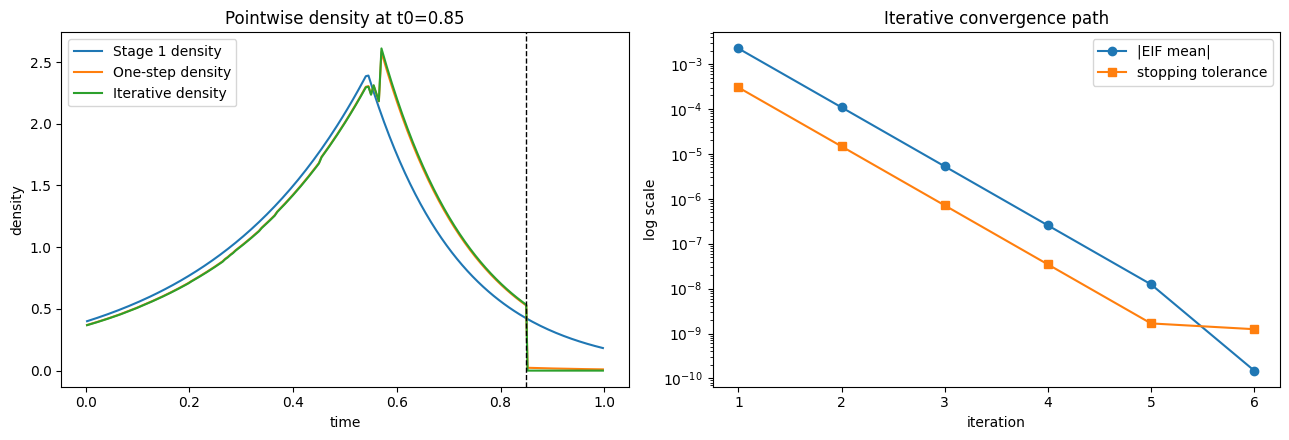

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    focus_one_step_fit['target_grid_midpoints'],
    focus_one_step_fit['density_before_grid'],
    label='Stage 1 density',
    color='tab:blue',
)
axes[0].plot(
    focus_one_step_fit['target_grid_midpoints'],
    focus_one_step_fit['estimated_density'],
    label='One-step density',
    color='tab:orange',
)
if focus_final_state is not None:
    axes[0].plot(
        focus_final_state.grid_midpoints,
        focus_final_state.density_grid,
        label='Iterative density',
        color='tab:green',
    )
axes[0].axvline(FOCUS_T0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title(f'Pointwise density at t0={FOCUS_T0:.2f}')
axes[0].set_xlabel('time')
axes[0].set_ylabel('density')
axes[0].legend()

axes[1].plot(
    focus_history['iteration'],
    np.abs(focus_history['eif_mean']),
    marker='o',
    label='|EIF mean|',
)
axes[1].plot(
    focus_history['iteration'],
    focus_history['stop_tolerance'],
    marker='s',
    label='stopping tolerance',
)
axes[1].set_yscale('log')
axes[1].set_title('Iterative convergence path')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('log scale')
axes[1].legend()

plt.tight_layout()
plt.show()

## Curve-Level Comparison

Now we run the iterative TMLE over a small grid of target times:
- always take the first TMLE update from the initial fit;
- continue beyond that first update only when the post-update EIF check exceeds the `sigma / (sqrt(n) log n)` tolerance.

This should leave most targets at one iteration while still allowing additional updates in the harder tail points.

In [22]:
curve_one_step = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=False,
)['summary'].copy()

curve_iterative_summary, curve_iterative_results = iterative_tmle_curve_from_initial(
    initial_fit=initial_fit,
    censoring_cache=censoring_cache,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    survival_clip=SURVIVAL_CLIP,
    max_iter=MAX_ITER,
    min_abs_eps=MIN_ABS_EPS,
    min_score_tol=MIN_SCORE_TOL,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
)
curve_step1_summary = pd.DataFrame(
    [summarize_tmle_step(result, step=1, n_obs=data.shape[0]) for result in curve_iterative_results]
)

curve_comparison = curve_one_step[
    ['t0', 'psi_init', 'psi_star']
].rename(
    columns={
        'psi_star': 'psi_one_step',
    }
).merge(
    curve_step1_summary[
        ['t0', 'psi_star', 'eif_mean', 'epsilon', 'sigma_over_sqrtnlogn']
    ].rename(
        columns={
            'psi_star': 'psi_one_step_local',
            'eif_mean': 'eif_mean_one_step',
            'epsilon': 'epsilon_one_step',
            'sigma_over_sqrtnlogn': 'sigma_over_sqrtnlogn_one_step',
        }
    ),
    on='t0',
    how='left',
).merge(
    curve_iterative_summary[
        ['t0', 'psi_star', 'eif_mean_final', 'n_iterations', 'continued_past_one_step', 'epsilon_last', 'threshold_final']
    ].rename(
        columns={
            'psi_star': 'psi_iterative',
            'eif_mean_final': 'eif_mean_iterative',
            'epsilon_last': 'epsilon_iterative_last',
            'threshold_final': 'threshold_iterative',
        }
    ),
    on='t0',
    how='left',
)
curve_comparison

,t0,psi_init,psi_one_step,psi_one_step_local,eif_mean_one_step,epsilon_one_step,sigma_over_sqrtnlogn_one_step,psi_iterative,eif_mean_iterative,n_iterations,continued_past_one_step,epsilon_iterative_last,threshold_iterative
0,0.001000,0.999602,1.000000e+00,1.000000e+00,4.578120e-19,34.398598,0.000000e+00,1.000000e+00,4.578120e-19,1,False,34.398598,1.000000e-15
1,0.053526,0.976739,1.000000e+00,1.000000e+00,5.552518e-23,47.507759,0.000000e+00,1.000000e+00,5.552518e-23,1,False,47.507759,1.000000e-15
2,0.106053,0.949522,1.000000e+00,1.000000e+00,9.863748e-18,35.947438,1.577827e-20,1.000000e+00,9.863748e-18,1,False,35.947438,1.000000e-15
3,0.158579,0.917120,1.000000e+00,1.000000e+00,3.424061e-18,36.968158,7.241400e-21,1.000000e+00,3.424061e-18,1,False,36.968158,1.000000e-15
4,0.211105,0.878548,1.000000e+00,1.000000e+00,2.786320e-23,48.588122,4.649688e-26,1.000000e+00,2.786320e-23,1,False,48.588122,1.000000e-15
5,0.263632,0.832629,1.000000e+00,1.000000e+00,1.964548e-20,41.876323,5.076818e-23,1.000000e+00,1.964548e-20,1,False,41.876323,1.000000e-15
6,0.316158,0.777964,1.000000e+00,1.000000e+00,2.141932e-17,34.791274,8.790621e-20,1.000000e+00,2.141932e-17,1,False,34.791274,1.000000e-15
7,0.368684,0.712888,8.266359e-01,8.266359e-01,-2.623147e-03,0.535910,2.900046e-02,8.266359e-01,-2.623147e-03,1,False,0.535910,2.900046e-02
8,0.421211,0.635418,7.651336e-01,7.651336e-01,-4.751070e-03,0.471810,3.309965e-02,7.651336e-01,-4.751070e-03,1,False,0.471810,3.309965e-02
9,0.473737,0.543193,6.311458e-01,6.311458e-01,-5.515567e-03,0.256163,3.843286e-02,6.311458e-01,-5.515567e-03,1,False,0.256163,3.843286e-02


In [23]:
# give me the eif for t0 = 0.368684

eif_t0 = 0.368684
eif_result = iterate_tmle_t0(
    initial_fit,
    censoring_cache,
    data,
    eif_t0,
    survival_clip=SURVIVAL_CLIP,
    max_iter=MAX_ITER,
    min_abs_eps=MIN_ABS_EPS,
    min_score_tol=MIN_SCORE_TOL,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
)
eif_step1 = summarize_tmle_step(eif_result, step=1, n_obs=data.shape[0])

if int(eif_result['summary']['n_iterations']) != 1:
    raise RuntimeError(
        f"This cell assumes t0={eif_t0} stops after one iteration, got n_iterations={eif_result['summary']['n_iterations']}"
    )

eif_values = np.asarray(eif_result['final_state'].eif_values, dtype=float)

pd.Series(
    {
        't0': eif_t0,
        'psi_star': eif_step1['psi_star'],
        'eif_mean': eif_step1['eif_mean'],
        'sigma': eif_step1['sigma'],
        'epsilon': eif_step1['epsilon'],
        'sigma_over_sqrtnlogn': eif_step1['sigma_over_sqrtnlogn'],
        'threshold_iterative': eif_step1['stop_tolerance'],
        'n_observations': int(eif_values.size),
    }
)

eif_values


array([ 0.20605515,  0.11290075,  0.16957811,  0.20707657,  0.20707657,
        0.20707657, -1.25997107,  0.20707657,  0.20707657,  0.01662896,
        0.20707657,  0.20707657, -1.17009787,  0.12152707, -1.25997107,
        0.20707657,  0.20707657,  0.20707657,  0.20707657,  0.20707657,
        0.10828465,  0.02555726,  0.20707657,  0.0661944 ,  0.1057398 ])

In [24]:
np.mean(eif_values) < np.sqrt(np.var(eif_values))/np.sqrt(len(eif_values))*np.log(len(eif_values))

np.True_

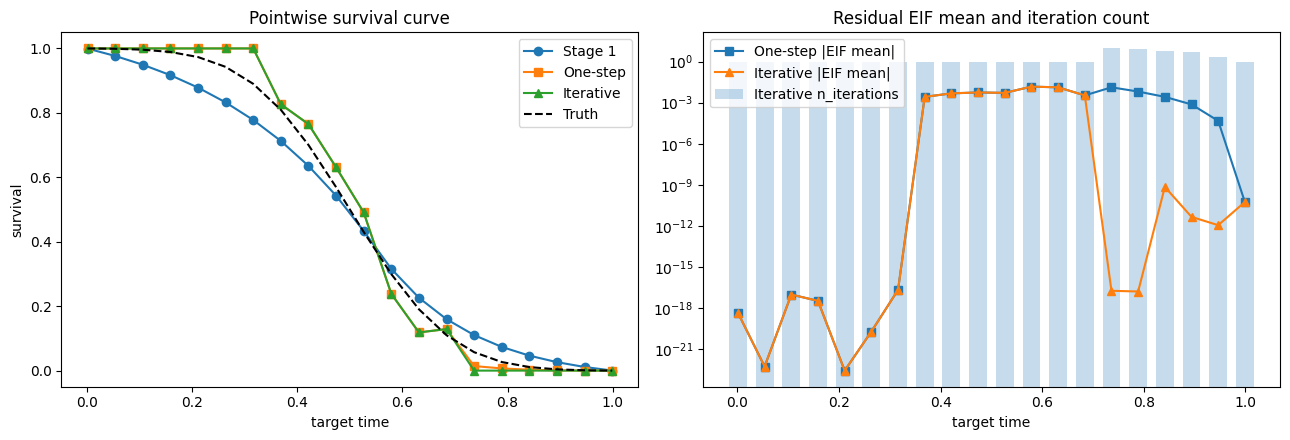

,t0,continued_past_one_step,n_iterations,epsilon_last,threshold_final,eif_mean_final
14,0.736368,True,9,-0.431063,1.136625e-09,-1.862194e-17
15,0.788895,True,8,-0.350110,1.195572e-09,-1.651448e-17
16,0.841421,True,6,-0.892801,1.183954e-09,-7.034319e-10
17,0.893947,True,5,-1.143611,1.308454e-09,-4.601907e-12
18,0.946474,True,2,-6.469385,1.353508e-09,-1.143675e-12
0,0.001000,False,1,34.398598,1.000000e-15,4.578120e-19
1,0.053526,False,1,47.507759,1.000000e-15,5.552518e-23
2,0.106053,False,1,35.947438,1.000000e-15,9.863748e-18
3,0.158579,False,1,36.968158,1.000000e-15,3.424061e-18
4,0.211105,False,1,48.588122,1.000000e-15,2.786320e-23


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

true_survival = truncnorm.sf(
    curve_comparison['t0'].to_numpy(dtype=float),
    a,
    b,
    loc=event_mean,
    scale=event_std,
)

axes[0].plot(curve_comparison['t0'], curve_comparison['psi_init'], marker='o', label='Stage 1')
axes[0].plot(curve_comparison['t0'], curve_comparison['psi_one_step'], marker='s', label='One-step')
axes[0].plot(curve_comparison['t0'], curve_comparison['psi_iterative'], marker='^', label='Iterative')
axes[0].plot(curve_comparison['t0'], true_survival, linestyle='--', color='black', label='Truth')
axes[0].set_title('Pointwise survival curve')
axes[0].set_xlabel('target time')
axes[0].set_ylabel('survival')
axes[0].legend()

axes[1].plot(curve_comparison['t0'], np.abs(curve_comparison['eif_mean_one_step']), marker='s', label='One-step |EIF mean|')
axes[1].plot(curve_comparison['t0'], np.abs(curve_comparison['eif_mean_iterative']), marker='^', label='Iterative |EIF mean|')
axes[1].bar(
    curve_iterative_summary['t0'],
    curve_iterative_summary['n_iterations'],
    width=0.035,
    alpha=0.25,
    label='Iterative n_iterations',
)
axes[1].set_yscale('log')
axes[1].set_title('Residual EIF mean and iteration count')
axes[1].set_xlabel('target time')
axes[1].legend()

plt.tight_layout()
plt.show()

curve_iterative_summary[
    ['t0', 'continued_past_one_step', 'n_iterations', 'epsilon_last', 'threshold_final', 'eif_mean_final']
].sort_values(['continued_past_one_step', 't0'], ascending=[False, True])

## Notes

This notebook is intentionally a demo rather than a package interface.

What it establishes:
- one fixed augmented grid per `t0` is enough for the iterative outer loop;
- the mutable state can be carried entirely through density, log-density, and survival arrays on that grid;
- iteration 1 is just the one-step TMLE update from the initial fit;
- the one-step row now reports the recomputed post-update `P_n D*^(1)` rather than the frozen solved score from the original one-dimensional submodel;
- continuation beyond iteration 1 can be governed by the post-update empirical EIF tolerance;
- the tail can need more than one local TMLE update even when most points stop after the first update.

If this behavior looks stable, the next step is to move these helpers into `learner.py` behind an `iterative=True` option while keeping the current one-step API as the default.